# Showcase — the 2023 Canadian wildfires (NASA FIRMS)

The 2023 wildfire season was Canada's worst on record. NASA's **FIRMS** (Fire Information for Resource Management System) publishes satellite thermal-anomaly / active-fire detections from MODIS and VIIRS. This notebook uses the earthlens **FIRMS** backend to pull a week of VIIRS detections over Quebec at the June 2023 peak and maps every fire pixel by its radiative power (FRP).

> Needs a free FIRMS `MAP_KEY` in the `FIRMS_MAP_KEY` environment variable (see the FIRMS docs); degrades gracefully without it.

In [1]:
import os, tempfile
import numpy as np, matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens

logger.disable("earthlens"); logger.disable("pyramids")

# VIIRS_SNPP_SP is the standard-processing (archive) product, so historical
# 2023 dates are available (the NRT products keep only ~2 months).
fires = None
if os.environ.get("FIRMS_MAP_KEY"):
    try:
        fires = EarthLens(
            data_source="firms", variables=["VIIRS_SNPP_SP"],
            start="2023-06-02", end="2023-06-08",
            lat_lim=[48.0, 53.0], lon_lim=[-80.0, -72.0],
            path=tempfile.mkdtemp(),
        ).download(progress_bar=False)
        print(f"{len(fires):,} fire detections")
    except Exception as exc:  # noqa: BLE001
        print("skipped FIRMS query:", exc)
else:
    print("set FIRMS_MAP_KEY to run this query")

24,702 fire detections


## Map every fire pixel by radiative power

Fire radiative power (FRP, in MW) scales with fire intensity.

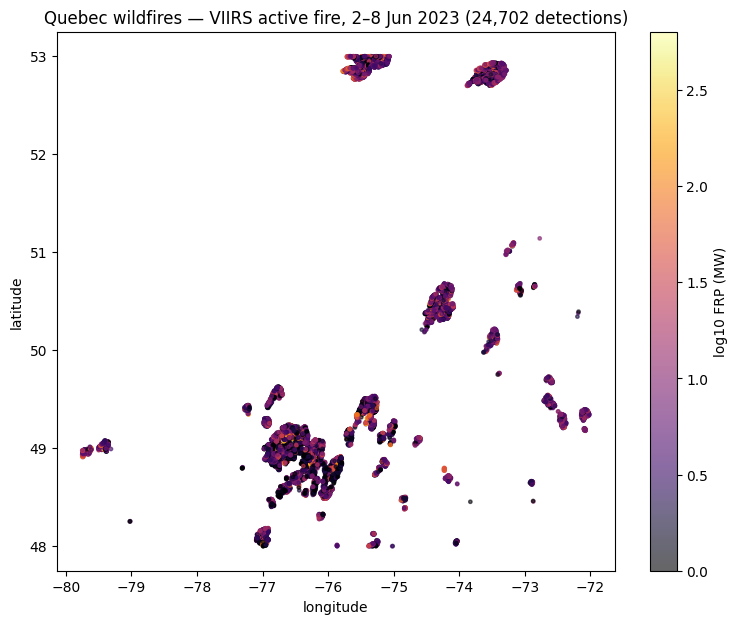

In [2]:
if fires is not None and len(fires):
    f = fires
    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(f["longitude"], f["latitude"], c=np.log10(f["frp"].clip(lower=1)),
                    cmap="inferno", s=6, alpha=0.6)
    ax.set(xlabel="longitude", ylabel="latitude",
           title=f"Quebec wildfires — VIIRS active fire, 2–8 Jun 2023 ({len(f):,} detections)")
    fig.colorbar(sc, ax=ax, label="log10 FRP (MW)")
    plt.show()
else:
    print("no detections to map")

## Detections per day

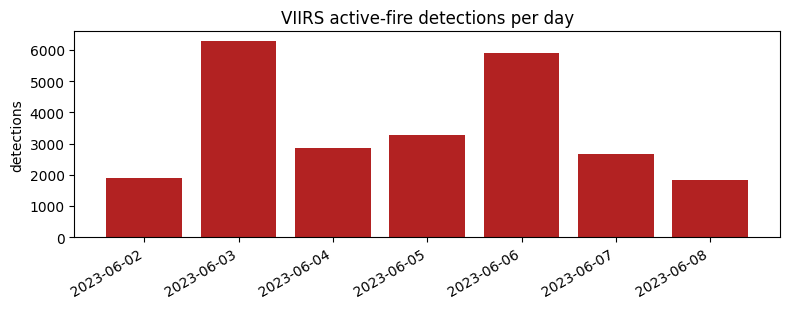

In [3]:
import pandas as pd
if fires is not None and len(fires):
    d = pd.to_datetime(fires["acq_datetime"], utc=True).dt.date.value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(8, 3.2))
    ax.bar([str(x) for x in d.index], d.values, color="firebrick")
    ax.set_ylabel("detections"); ax.set_title("VIIRS active-fire detections per day")
    plt.xticks(rotation=30, ha="right"); plt.tight_layout(); plt.show()
else:
    print("no detections")